In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Credit Risk & Stress Testing")
print("Public Company Portfolio Analysis")
print("Libraries loaded successfully.")

Credit Risk & Stress Testing
Public Company Portfolio Analysis
Libraries loaded successfully.


# Corporate Credit Risk & Stress Testing

## Public Company Portfolio Analysis

This project examines the credit profiles of six large public companies across different sectors using financial data from their FY2025 annual filings.

The analysis focuses on leverage, debt-servicing capacity and liquidity before testing how these measures change under adverse operating and financing conditions.

The project then uses the results to examine expected credit losses and portfolio concentration.

### Companies analysed

- Verizon Communications — Telecommunications
- Exxon Mobil — Energy
- PepsiCo — Consumer Staples
- Cisco Systems — Technology
- Union Pacific — Industrials
- FedEx — Transportation

All financial figures are presented in US$ millions unless otherwise stated.

The credit-risk framework developed in this project is an illustrative analytical model. It is not intended to replicate the methodology of a credit-rating agency or predict actual defaults.

### Project Overview

This project develops an illustrative corporate credit-risk framework using FY2025 financial data from six large US-listed companies across different sectors.

The analysis moves from borrower-level financial metrics to portfolio-level risk assessment, combining leverage, interest coverage, liquidity, stress testing, expected loss and concentration analysis.

The objective is to demonstrate how financial statement data can be transformed into a structured credit-risk assessment and how borrower-level vulnerabilities can translate into portfolio-level risk.

### Analysis Roadmap

The project follows five stages:

**1. Portfolio Construction**  
Six public companies are selected across different sectors using FY2025 financial data.

**2. Credit Profile Assessment**  
Leverage, interest coverage and liquidity metrics are calculated to assess borrower-level financial resilience.

**3. Portfolio Risk Analysis**  
Borrower and sector concentration are examined alongside qualitative company-specific risk factors.

**4. Stress Testing and Expected Loss**  
Operating and financing assumptions are stressed to evaluate changes in credit metrics and estimated expected losses.

**5. Interpretation and Limitations**  
The results are interpreted at both borrower and portfolio level, with the model's assumptions and limitations explicitly considered.

In [2]:
portfolio_data = {
    "Company": [
        "Verizon Communications",
        "Exxon Mobil",
        "PepsiCo",
        "Cisco Systems",
        "Union Pacific",
        "FedEx"
    ],

    "Ticker": [
        "VZ",
        "XOM",
        "PEP",
        "CSCO",
        "UNP",
        "FDX"
    ],

    "Sector": [
        "Telecommunications",
        "Energy",
        "Consumer Staples",
        "Technology",
        "Industrials",
        "Transportation"
    ],

    "Reporting_Period": [
        "FY2025 - Dec 31",
        "FY2025 - Dec 31",
        "FY2025 - Dec 27",
        "FY2025 - Jul 26",
        "FY2025 - Dec 31",
        "FY2025 - May 31"
    ],

    # All financial figures below are US$ millions
    "Total_Debt": [
        158150,
        43537,
        49182,
        28093,
        31814,
        19899
    ],

    "EBITDA": [
        47715,
        56944,
        14949,
        15504,
        12940,
        10494
    ],

    "Interest_Expense": [
        6694,
        603,
        1840,
        1593,
        1309,
        789
    ],

    "Cash": [
        19048,
        10681,
        9159,
        8346,
        1266,
        5502
    ],

    "Short_Term_Debt": [
        18618,
        9296,
        6861,
        5232,
        1520,
        1371
    ]
}

df = pd.DataFrame(portfolio_data)

df

,Company,Ticker,Sector,Reporting_Period,Total_Debt,EBITDA,Interest_Expense,Cash,Short_Term_Debt
0,Verizon Communications,VZ,Telecommunications,FY2025 - Dec 31,158150,47715,6694,19048,18618
1,Exxon Mobil,XOM,Energy,FY2025 - Dec 31,43537,56944,603,10681,9296
2,PepsiCo,PEP,Consumer Staples,FY2025 - Dec 27,49182,14949,1840,9159,6861
3,Cisco Systems,CSCO,Technology,FY2025 - Jul 26,28093,15504,1593,8346,5232
4,Union Pacific,UNP,Industrials,FY2025 - Dec 31,31814,12940,1309,1266,1520
5,FedEx,FDX,Transportation,FY2025 - May 31,19899,10494,789,5502,1371


Data and Methodology: The analysis uses financial data from the latest completed FY2025 annual filings of six publicly listed companies.

The companies operate across different sectors and have different fiscal year-end dates. The reporting period shown in the dataset reflects each company's actual FY2025 reporting date.

Core variables

* Total Debt: total reported debt outstanding
* EBITDA:standardised measure of operating earnings
* Interest Expense: reported interest expenseCash: cash and cash equivalents
* Short-Term Debt: debt due within one year
* EBITDA methodology: To improve comparability across companies, EBITDA is standardised rather than relying on each company's own adjusted EBITDA definition.


Where the required components are available: EBITDA = Net Income + Tax Expense + Interest Expense + Depreciation & Amortisation

This creates a consistent measure across the portfolio.

All financial figures are presented in US$ millions. The figures are historical reported data and do not represent forecasts.

In [3]:
# Calculate core credit metrics

df["Net_Debt"] = df["Total_Debt"] - df["Cash"]

df["Gross_Leverage"] = (
    df["Total_Debt"] / df["EBITDA"]
)

df["Net_Leverage"] = (
    df["Net_Debt"] / df["EBITDA"]
)

df["Interest_Coverage"] = (
    df["EBITDA"] / df["Interest_Expense"]
)

df["Liquidity_Coverage"] = (
    df["Cash"] / df["Short_Term_Debt"]
)

df[[
    "Company",
    "Ticker",
    "Gross_Leverage",
    "Net_Leverage",
    "Interest_Coverage",
    "Liquidity_Coverage"
]]

,Company,Ticker,Gross_Leverage,Net_Leverage,Interest_Coverage,Liquidity_Coverage
0,Verizon Communications,VZ,3.314471,2.915268,7.128025,1.023096
1,Exxon Mobil,XOM,0.764558,0.576988,94.434494,1.148989
2,PepsiCo,PEP,3.289986,2.677303,8.124457,1.334937
3,Cisco Systems,CSCO,1.811984,1.273671,9.732580,1.595183
4,Union Pacific,UNP,2.458578,2.360742,9.885409,0.832895
5,FedEx,FDX,1.896226,1.371927,13.300380,4.013129


In [39]:
# Create a clean presentation view of the underlying company data

company_data_display = df[[
    "Company",
    "Ticker",
    "Sector",
    "Reporting_Period",
    "Total_Debt",
    "EBITDA",
    "Interest_Expense",
    "Cash",
    "Short_Term_Debt"
]].copy()

company_data_display.columns = [
    "Company",
    "Ticker",
    "Sector",
    "Reporting Period",
    "Total Debt",
    "EBITDA",
    "Interest Expense",
    "Cash",
    "Short-Term Debt"
]

company_data_display

,Company,Ticker,Sector,Reporting Period,Total Debt,EBITDA,Interest Expense,Cash,Short-Term Debt
0,Verizon Communications,VZ,Telecommunications,FY2025 - Dec 31,158150,47715,6694,19048,18618
1,Exxon Mobil,XOM,Energy,FY2025 - Dec 31,43537,56944,603,10681,9296
2,PepsiCo,PEP,Consumer Staples,FY2025 - Dec 27,49182,14949,1840,9159,6861
3,Cisco Systems,CSCO,Technology,FY2025 - Jul 26,28093,15504,1593,8346,5232
4,Union Pacific,UNP,Industrials,FY2025 - Dec 31,31814,12940,1309,1266,1520
5,FedEx,FDX,Transportation,FY2025 - May 31,19899,10494,789,5502,1371


In [40]:
# Check the underlying dataset for missing values and duplicate companies

data_quality_check = pd.DataFrame({
    "Metric": [
        "Number of companies",
        "Number of sectors",
        "Missing values",
        "Duplicate company records"
    ],
    "Value": [
        df["Company"].nunique(),
        df["Sector"].nunique(),
        df.isna().sum().sum(),
        df["Company"].duplicated().sum()
    ]
})

data_quality_check

,Metric,Value
0,Number of companies,6
1,Number of sectors,6
2,Missing values,0
3,Duplicate company records,0


> **Note:** All financial figures are reported in US$ millions. Ratios such as leverage, interest coverage and liquidity coverage are expressed as multiples (×), while probability of default and portfolio exposure percentages are expressed as percentages.

In [4]:
# Clean comparison table

credit_comparison = df[[
    "Company",
    "Ticker",
    "Sector",
    "Gross_Leverage",
    "Net_Leverage",
    "Interest_Coverage",
    "Liquidity_Coverage"
]].copy()

credit_comparison = credit_comparison.sort_values(
    "Net_Leverage"
)

credit_comparison

,Company,Ticker,Sector,Gross_Leverage,Net_Leverage,Interest_Coverage,Liquidity_Coverage
1,Exxon Mobil,XOM,Energy,0.764558,0.576988,94.434494,1.148989
3,Cisco Systems,CSCO,Technology,1.811984,1.273671,9.732580,1.595183
5,FedEx,FDX,Transportation,1.896226,1.371927,13.300380,4.013129
4,Union Pacific,UNP,Industrials,2.458578,2.360742,9.885409,0.832895
2,PepsiCo,PEP,Consumer Staples,3.289986,2.677303,8.124457,1.334937
0,Verizon Communications,VZ,Telecommunications,3.314471,2.915268,7.128025,1.023096


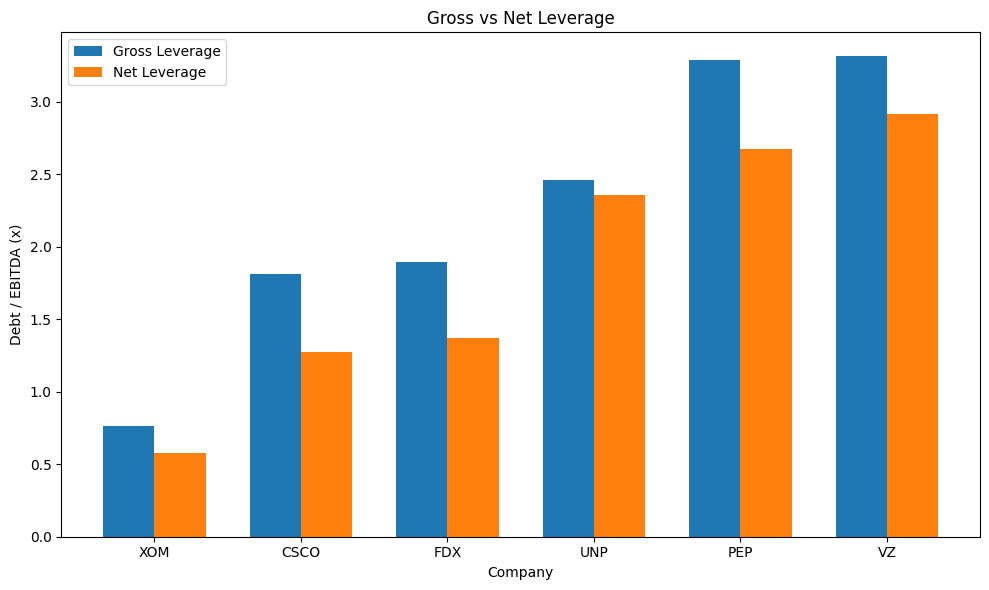

In [5]:
# Compare gross and net leverage

leverage_plot = df.sort_values("Net_Leverage")

plt.figure(figsize=(10, 6))

x = np.arange(len(leverage_plot))
width = 0.35

plt.bar(
    x - width / 2,
    leverage_plot["Gross_Leverage"],
    width,
    label="Gross Leverage"
)

plt.bar(
    x + width / 2,
    leverage_plot["Net_Leverage"],
    width,
    label="Net Leverage"
)

plt.xticks(
    x,
    leverage_plot["Ticker"]
)

plt.ylabel("Debt / EBITDA (x)")
plt.xlabel("Company")
plt.title("Gross vs Net Leverage")
plt.legend()

plt.tight_layout()
plt.show()

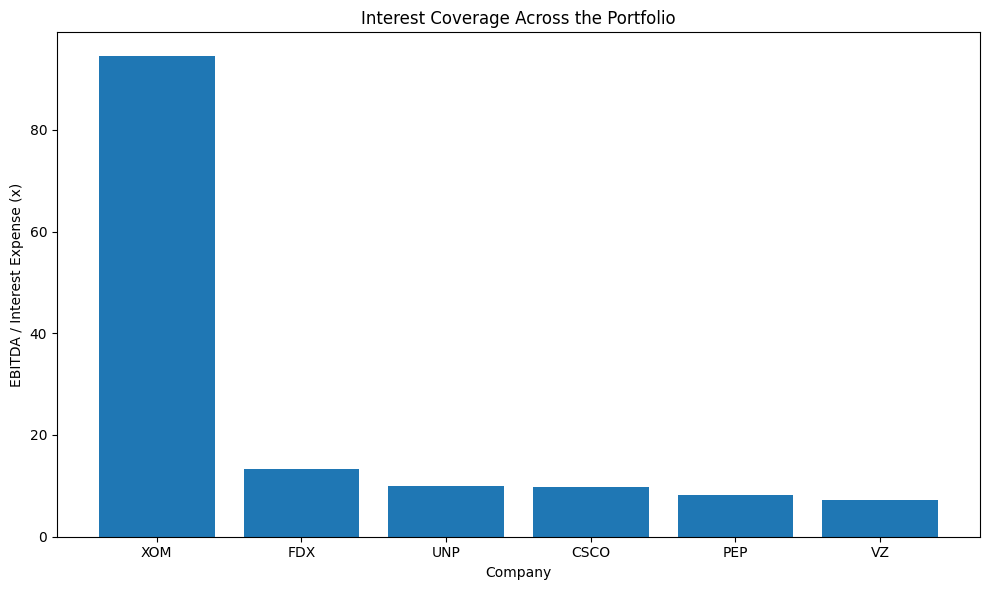

In [6]:
# Compare interest coverage

coverage_plot = df.sort_values("Interest_Coverage", ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    coverage_plot["Ticker"],
    coverage_plot["Interest_Coverage"]
)

plt.ylabel("EBITDA / Interest Expense (x)")
plt.xlabel("Company")
plt.title("Interest Coverage Across the Portfolio")

plt.tight_layout()
plt.show()

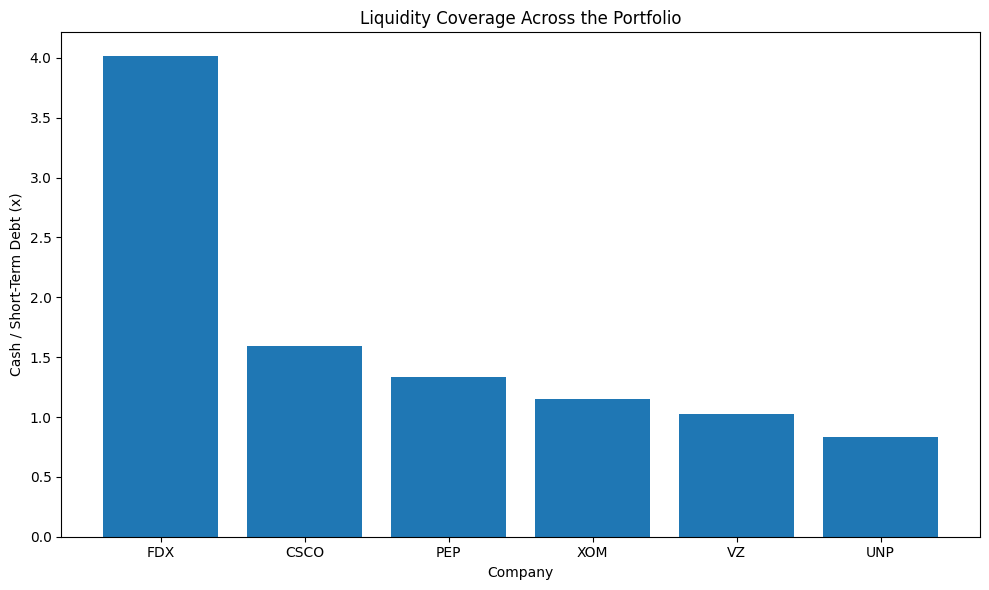

In [7]:
# Compare liquidity coverage

liquidity_plot = df.sort_values("Liquidity_Coverage", ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    liquidity_plot["Ticker"],
    liquidity_plot["Liquidity_Coverage"]
)

plt.ylabel("Cash / Short-Term Debt (x)")
plt.xlabel("Company")
plt.title("Liquidity Coverage Across the Portfolio")

plt.tight_layout()
plt.show()

In [8]:
# Portfolio summary statistics

summary_stats = df[[
    "Gross_Leverage",
    "Net_Leverage",
    "Interest_Coverage",
    "Liquidity_Coverage"
]].describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
Gross_Leverage,6.0,2.255967,0.977907,0.764558,1.833045,2.177402,3.082134,3.314471
Net_Leverage,6.0,1.862650,0.923081,0.576988,1.298235,1.866334,2.598163,2.915268
Interest_Coverage,6.0,23.767557,34.683290,7.128025,8.526487,9.808994,12.446637,94.434494
Liquidity_Coverage,6.0,1.658038,1.183042,0.832895,1.054569,1.241963,1.530122,4.013129


In [9]:
# Build an illustrative credit resilience score

def percentile_score(series, higher_is_better=True):
    ranks = series.rank(pct=True)
    
    if higher_is_better:
        return ranks * 100
    else:
        return (1 - ranks + (1 / len(series))) * 100


df["Net_Leverage_Score"] = percentile_score(
    df["Net_Leverage"],
    higher_is_better=False
)

df["Gross_Leverage_Score"] = percentile_score(
    df["Gross_Leverage"],
    higher_is_better=False
)

df["Interest_Coverage_Score"] = percentile_score(
    df["Interest_Coverage"],
    higher_is_better=True
)

df["Liquidity_Coverage_Score"] = percentile_score(
    df["Liquidity_Coverage"],
    higher_is_better=True
)

df["Credit_Resilience_Score"] = (
    0.30 * df["Net_Leverage_Score"]
    + 0.30 * df["Interest_Coverage_Score"]
    + 0.20 * df["Liquidity_Coverage_Score"]
    + 0.20 * df["Gross_Leverage_Score"]
)

df[[
    "Company",
    "Ticker",
    "Net_Leverage_Score",
    "Interest_Coverage_Score",
    "Liquidity_Coverage_Score",
    "Credit_Resilience_Score"
]].sort_values(
    "Credit_Resilience_Score",
    ascending=False
)

,Company,Ticker,Net_Leverage_Score,Interest_Coverage_Score,Liquidity_Coverage_Score,Credit_Resilience_Score
1,Exxon Mobil,XOM,100.000000,100.000000,50.000000,90.000000
5,FedEx,FDX,66.666667,83.333333,100.000000,78.333333
3,Cisco Systems,CSCO,83.333333,50.000000,83.333333,73.333333
4,Union Pacific,UNP,50.000000,66.666667,16.666667,48.333333
2,PepsiCo,PEP,33.333333,33.333333,66.666667,40.000000
0,Verizon Communications,VZ,16.666667,16.666667,33.333333,20.000000


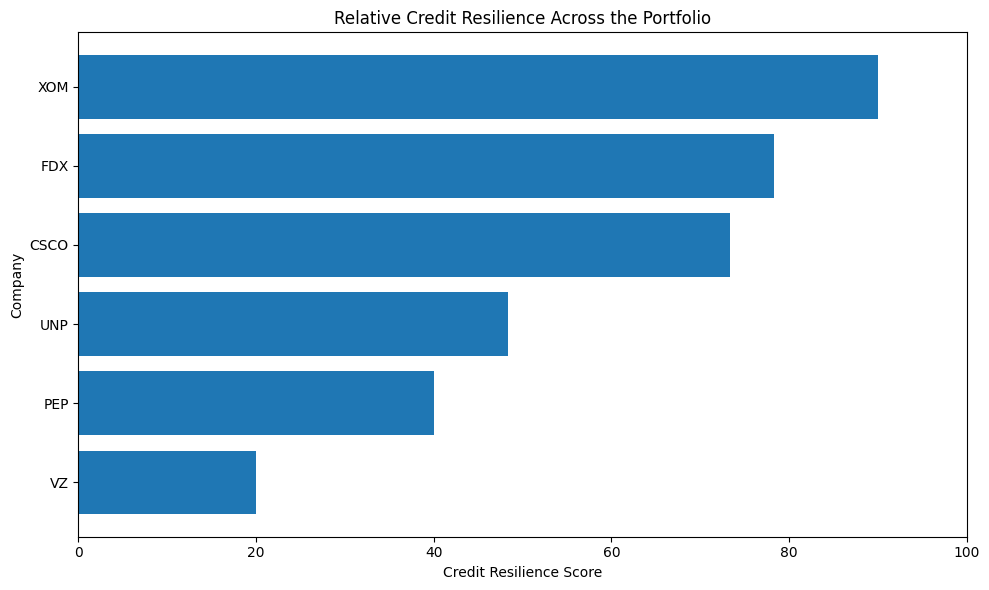

In [10]:
# Plot the credit resilience score

score_plot = df.sort_values("Credit_Resilience_Score")

plt.figure(figsize=(10, 6))

plt.barh(
    score_plot["Ticker"],
    score_plot["Credit_Resilience_Score"]
)

plt.xlabel("Credit Resilience Score")
plt.ylabel("Company")
plt.title("Relative Credit Resilience Across the Portfolio")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

In [11]:
# Define illustrative stress scenarios

stress_scenarios = {
    "Base": {
        "EBITDA_change": 0.00,
        "Interest_change": 0.00,
        "Cash_change": 0.00
    },
    "Moderate": {
        "EBITDA_change": -0.10,
        "Interest_change": 0.10,
        "Cash_change": -0.05
    },
    "Severe": {
        "EBITDA_change": -0.20,
        "Interest_change": 0.25,
        "Cash_change": -0.10
    },
    "Combined": {
        "EBITDA_change": -0.30,
        "Interest_change": 0.35,
        "Cash_change": -0.15
    }
}

stress_scenarios

{'Base': {'EBITDA_change': 0.0, 'Interest_change': 0.0, 'Cash_change': 0.0},
 'Moderate': {'EBITDA_change': -0.1,
  'Interest_change': 0.1,
  'Cash_change': -0.05},
 'Severe': {'EBITDA_change': -0.2,
  'Interest_change': 0.25,
  'Cash_change': -0.1},
 'Combined': {'EBITDA_change': -0.3,
  'Interest_change': 0.35,
  'Cash_change': -0.15}}

In [12]:
# Apply stress scenarios to the portfolio

stress_results = []

for _, row in df.iterrows():
    for scenario, assumptions in stress_scenarios.items():

        stressed_ebitda = (
            row["EBITDA"]
            * (1 + assumptions["EBITDA_change"])
        )

        stressed_interest = (
            row["Interest_Expense"]
            * (1 + assumptions["Interest_change"])
        )

        stressed_cash = (
            row["Cash"]
            * (1 + assumptions["Cash_change"])
        )

        stressed_net_debt = (
            row["Total_Debt"] - stressed_cash
        )

        stressed_gross_leverage = (
            row["Total_Debt"] / stressed_ebitda
        )

        stressed_net_leverage = (
            stressed_net_debt / stressed_ebitda
        )

        stressed_interest_coverage = (
            stressed_ebitda / stressed_interest
        )

        stressed_liquidity = (
            stressed_cash / row["Short_Term_Debt"]
        )

        stress_results.append({
            "Company": row["Company"],
            "Ticker": row["Ticker"],
            "Scenario": scenario,
            "EBITDA": stressed_ebitda,
            "Interest_Expense": stressed_interest,
            "Cash": stressed_cash,
            "Net_Debt": stressed_net_debt,
            "Gross_Leverage": stressed_gross_leverage,
            "Net_Leverage": stressed_net_leverage,
            "Interest_Coverage": stressed_interest_coverage,
            "Liquidity_Coverage": stressed_liquidity
        })

stress_df = pd.DataFrame(stress_results)

stress_df.head(10)

,Company,Ticker,Scenario,EBITDA,Interest_Expense,Cash,Net_Debt,Gross_Leverage,Net_Leverage,Interest_Coverage,Liquidity_Coverage
0,Verizon Communications,VZ,Base,47715.0,6694.00,19048.00,139102.00,3.314471,2.915268,7.128025,1.023096
1,Verizon Communications,VZ,Moderate,42943.5,7363.40,18095.60,140054.40,3.682746,3.261364,5.832021,0.971941
2,Verizon Communications,VZ,Severe,38172.0,8367.50,17143.20,141006.80,4.143089,3.693985,4.561936,0.920786
3,Verizon Communications,VZ,Combined,33400.5,9036.90,16190.80,141959.20,4.734959,4.250212,3.696013,0.869632
4,Exxon Mobil,XOM,Base,56944.0,603.00,10681.00,32856.00,0.764558,0.576988,94.434494,1.148989
5,Exxon Mobil,XOM,Moderate,51249.6,663.30,10146.95,33390.05,0.849509,0.651518,77.264586,1.091539
6,Exxon Mobil,XOM,Severe,45555.2,753.75,9612.90,33924.10,0.955698,0.744681,60.438076,1.034090
7,Exxon Mobil,XOM,Combined,39860.8,814.05,9078.85,34458.15,1.092226,0.864462,48.966034,0.976640
8,PepsiCo,PEP,Base,14949.0,1840.00,9159.00,40023.00,3.289986,2.677303,8.124457,1.334937
9,PepsiCo,PEP,Moderate,13454.1,2024.00,8701.05,40480.95,3.655540,3.008819,6.647283,1.268190


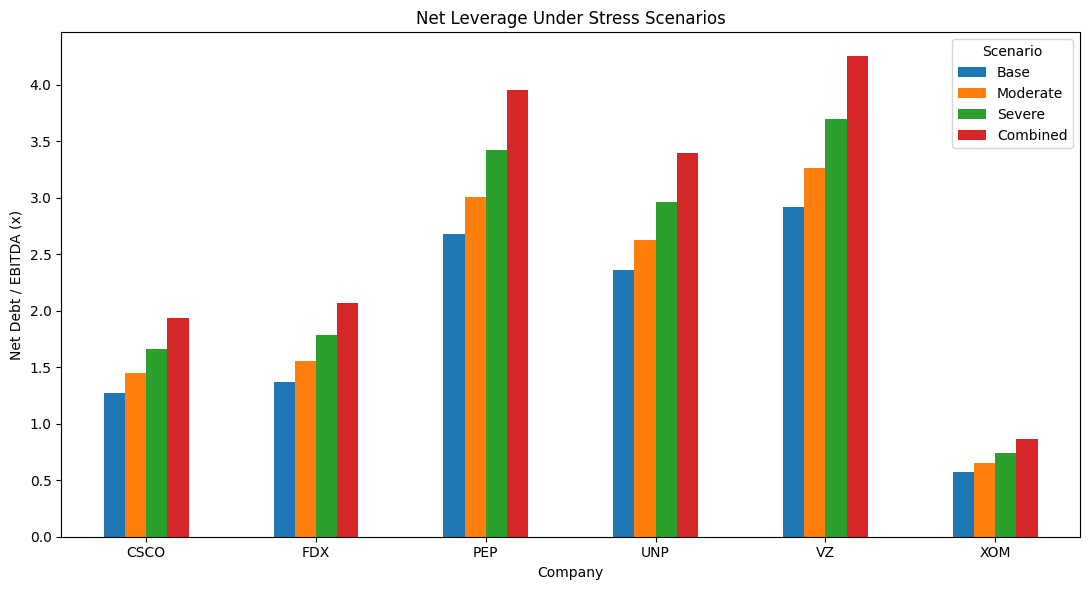

In [13]:
# Compare net leverage across stress scenarios

leverage_stress_plot = stress_df.pivot(
    index="Ticker",
    columns="Scenario",
    values="Net_Leverage"
)

scenario_order = ["Base", "Moderate", "Severe", "Combined"]

leverage_stress_plot = leverage_stress_plot[scenario_order]

leverage_stress_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Net Debt / EBITDA (x)")
plt.xlabel("Company")
plt.title("Net Leverage Under Stress Scenarios")
plt.xticks(rotation=0)
plt.legend(title="Scenario")

plt.tight_layout()
plt.show()

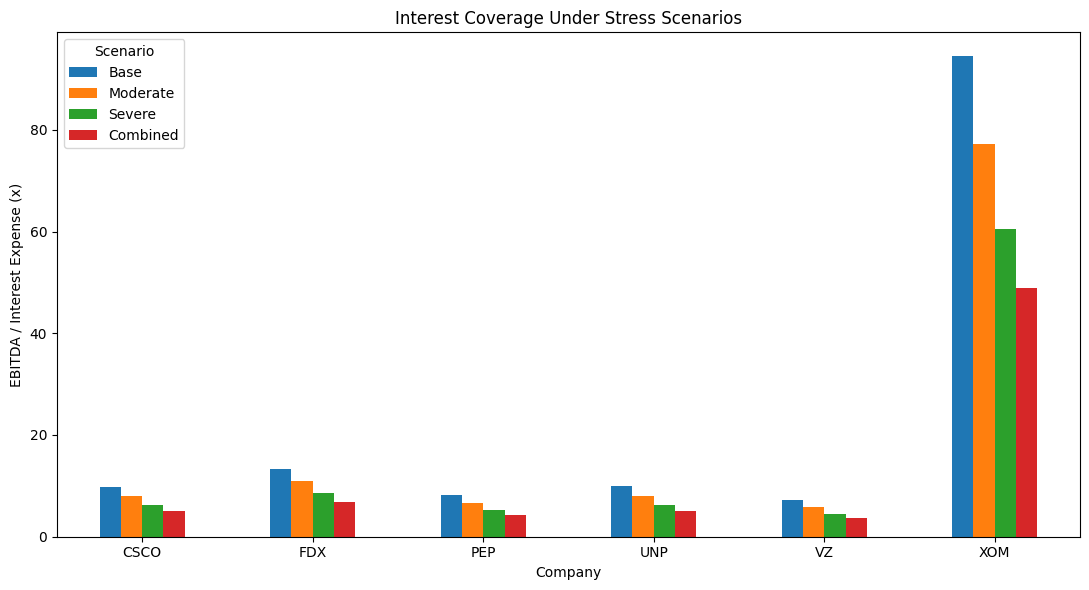

In [14]:
# Compare interest coverage across stress scenarios

coverage_stress_plot = stress_df.pivot(
    index="Ticker",
    columns="Scenario",
    values="Interest_Coverage"
)

coverage_stress_plot = coverage_stress_plot[
    ["Base", "Moderate", "Severe", "Combined"]
]

coverage_stress_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("EBITDA / Interest Expense (x)")
plt.xlabel("Company")
plt.title("Interest Coverage Under Stress Scenarios")
plt.xticks(rotation=0)
plt.legend(title="Scenario")

plt.tight_layout()
plt.show()

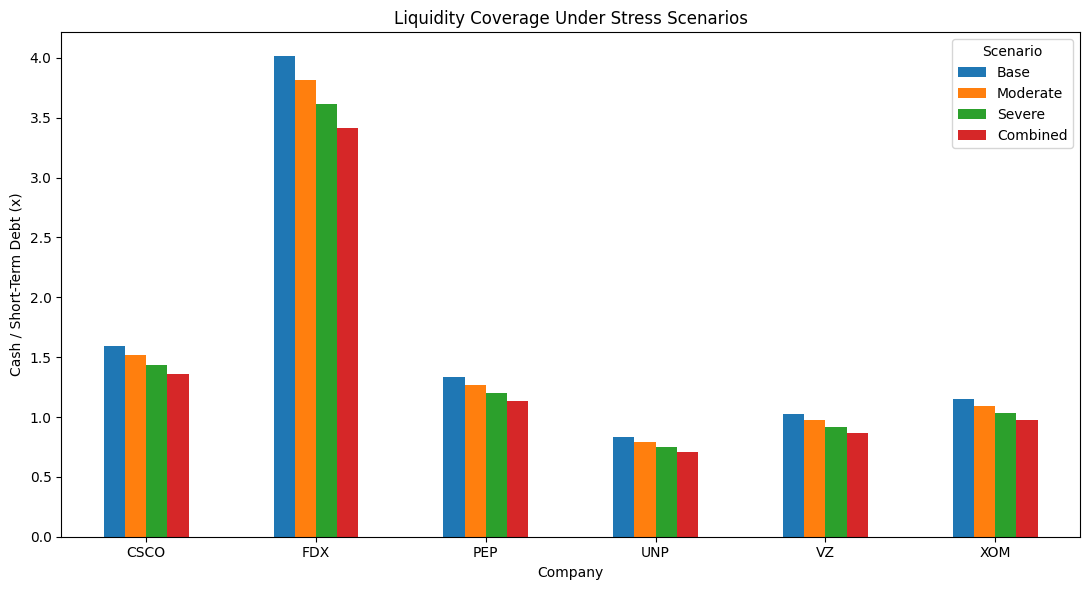

In [15]:
# Compare liquidity coverage across stress scenarios

liquidity_stress_plot = stress_df.pivot(
    index="Ticker",
    columns="Scenario",
    values="Liquidity_Coverage"
)

liquidity_stress_plot = liquidity_stress_plot[
    ["Base", "Moderate", "Severe", "Combined"]
]

liquidity_stress_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Cash / Short-Term Debt (x)")
plt.xlabel("Company")
plt.title("Liquidity Coverage Under Stress Scenarios")
plt.xticks(rotation=0)
plt.legend(title="Scenario")

plt.tight_layout()
plt.show()

In [16]:
base_metrics = stress_df[
    stress_df["Scenario"] == "Base"
].set_index("Ticker")

combined_metrics = stress_df[
    stress_df["Scenario"] == "Combined"
].set_index("Ticker")

deterioration_df = pd.DataFrame(index=df["Ticker"])

deterioration_df["Net_Leverage_Increase_%"] = (
    (combined_metrics["Net_Leverage"] / base_metrics["Net_Leverage"] - 1)
    * 100
)

deterioration_df["Interest_Coverage_Decline_%"] = (
    (1 - combined_metrics["Interest_Coverage"] / base_metrics["Interest_Coverage"])
    * 100
)

deterioration_df["Liquidity_Decline_%"] = (
    (1 - combined_metrics["Liquidity_Coverage"] / base_metrics["Liquidity_Coverage"])
    * 100
)

deterioration_df = deterioration_df.reset_index()

deterioration_df

,Ticker,Net_Leverage_Increase_%,Interest_Coverage_Decline_%,Liquidity_Decline_%
0,VZ,45.791475,48.148148,15.0
1,XOM,49.823255,48.148148,15.0
2,PEP,47.760930,48.148148,15.0
3,CSCO,51.913853,48.148148,15.0
4,UNP,43.745207,48.148148,15.0
5,FDX,51.046349,48.148148,15.0


In [17]:
# Calculate an illustrative stress sensitivity score

deterioration_df["Stress_Sensitivity_Score"] = (
    (
        deterioration_df["Net_Leverage_Increase_%"]
        + deterioration_df["Interest_Coverage_Decline_%"]
        + deterioration_df["Liquidity_Decline_%"]
    ) / 3
)

deterioration_df = deterioration_df.sort_values(
    "Stress_Sensitivity_Score",
    ascending=False
)

deterioration_df

,Ticker,Net_Leverage_Increase_%,Interest_Coverage_Decline_%,Liquidity_Decline_%,Stress_Sensitivity_Score
3,CSCO,51.913853,48.148148,15.0,38.354000
5,FDX,51.046349,48.148148,15.0,38.064832
1,XOM,49.823255,48.148148,15.0,37.657134
2,PEP,47.760930,48.148148,15.0,36.969693
0,VZ,45.791475,48.148148,15.0,36.313208
4,UNP,43.745207,48.148148,15.0,35.631118


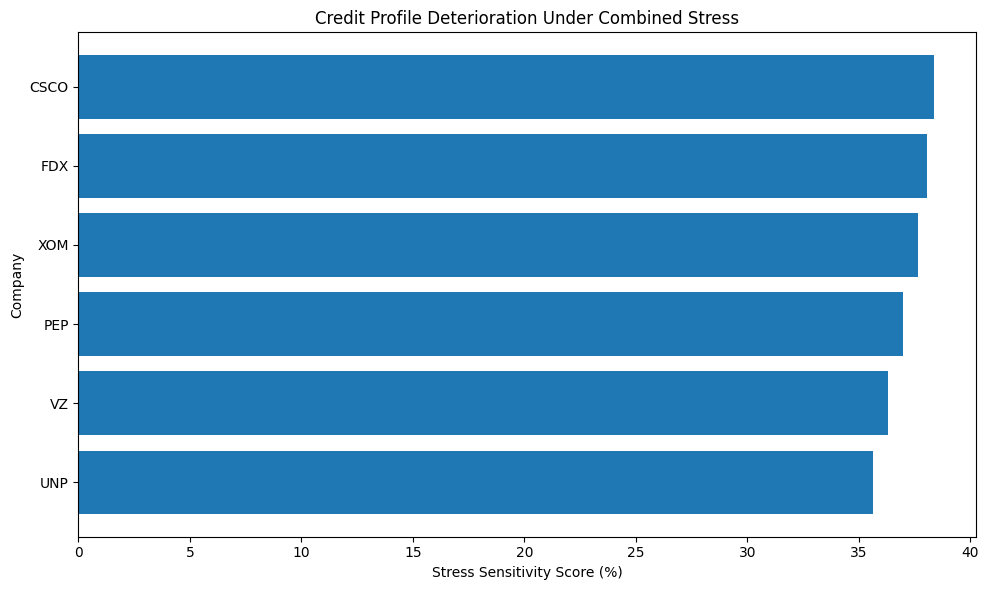

In [18]:
# Visualise stress sensitivity

stress_plot = deterioration_df.sort_values(
    "Stress_Sensitivity_Score"
)

plt.figure(figsize=(10, 6))

plt.barh(
    stress_plot["Ticker"],
    stress_plot["Stress_Sensitivity_Score"]
)

plt.xlabel("Stress Sensitivity Score (%)")
plt.ylabel("Company")
plt.title("Credit Profile Deterioration Under Combined Stress")

plt.tight_layout()
plt.show()

In [19]:
# Compare base case with combined stress

base_summary = stress_df[
    stress_df["Scenario"] == "Base"
][[
    "Ticker",
    "Net_Leverage",
    "Interest_Coverage",
    "Liquidity_Coverage"
]].copy()

combined_summary = stress_df[
    stress_df["Scenario"] == "Combined"
][[
    "Ticker",
    "Net_Leverage",
    "Interest_Coverage",
    "Liquidity_Coverage"
]].copy()

base_summary = base_summary.rename(columns={
    "Net_Leverage": "Base_Net_Leverage",
    "Interest_Coverage": "Base_Interest_Coverage",
    "Liquidity_Coverage": "Base_Liquidity_Coverage"
})

combined_summary = combined_summary.rename(columns={
    "Net_Leverage": "Stress_Net_Leverage",
    "Interest_Coverage": "Stress_Interest_Coverage",
    "Liquidity_Coverage": "Stress_Liquidity_Coverage"
})

stress_comparison = base_summary.merge(
    combined_summary,
    on="Ticker"
)

stress_comparison

,Ticker,Base_Net_Leverage,Base_Interest_Coverage,Base_Liquidity_Coverage,Stress_Net_Leverage,Stress_Interest_Coverage,Stress_Liquidity_Coverage
0,VZ,2.915268,7.128025,1.023096,4.250212,3.696013,0.869632
1,XOM,0.576988,94.434494,1.148989,0.864462,48.966034,0.976640
2,PEP,2.677303,8.124457,1.334937,3.956008,4.212681,1.134696
3,CSCO,1.273671,9.732580,1.595183,1.934883,5.046523,1.355906
4,UNP,2.360742,9.885409,0.832895,3.393453,5.125767,0.707961
5,FDX,1.371927,13.300380,4.013129,2.072245,6.896493,3.411160


In [20]:
# Calculate absolute changes from base to combined stress

stress_comparison["Net_Leverage_Change"] = (
    stress_comparison["Stress_Net_Leverage"]
    - stress_comparison["Base_Net_Leverage"]
)

stress_comparison["Interest_Coverage_Change"] = (
    stress_comparison["Stress_Interest_Coverage"]
    - stress_comparison["Base_Interest_Coverage"]
)

stress_comparison["Liquidity_Coverage_Change"] = (
    stress_comparison["Stress_Liquidity_Coverage"]
    - stress_comparison["Base_Liquidity_Coverage"]
)

stress_comparison

,Ticker,Base_Net_Leverage,Base_Interest_Coverage,Base_Liquidity_Coverage,Stress_Net_Leverage,Stress_Interest_Coverage,Stress_Liquidity_Coverage,Net_Leverage_Change,Interest_Coverage_Change,Liquidity_Coverage_Change
0,VZ,2.915268,7.128025,1.023096,4.250212,3.696013,0.869632,1.334944,-3.432012,-0.153464
1,XOM,0.576988,94.434494,1.148989,0.864462,48.966034,0.976640,0.287474,-45.468460,-0.172348
2,PEP,2.677303,8.124457,1.334937,3.956008,4.212681,1.134696,1.278705,-3.911775,-0.200240
3,CSCO,1.273671,9.732580,1.595183,1.934883,5.046523,1.355906,0.661212,-4.686057,-0.239278
4,UNP,2.360742,9.885409,0.832895,3.393453,5.125767,0.707961,1.032711,-4.759641,-0.124934
5,FDX,1.371927,13.300380,4.013129,2.072245,6.896493,3.411160,0.700319,-6.403887,-0.601969


## Expected Credit Loss

Expected credit loss is estimated using the simplified relationship:

**Expected Loss = Probability of Default × Loss Given Default × Exposure at Default**

For this illustrative portfolio model:

- **Probability of Default (PD)** is estimated from the model's Credit Resilience Score.
- **Loss Given Default (LGD)** is assumed to be 40%.
- **Exposure at Default (EAD)** is approximated using total reported debt.

These assumptions are illustrative and are not intended to represent market-implied default probabilities, recovery estimates or actual lender exposures.

The purpose of the analysis is to demonstrate how a credit-risk framework can translate financial risk indicators into an estimated loss measure.

In [21]:
# Assign illustrative probability of default (PD)

def assign_pd(score):
    if score >= 80:
        return 0.01
    elif score >= 60:
        return 0.02
    elif score >= 40:
        return 0.04
    elif score >= 20:
        return 0.08
    else:
        return 0.15


df["Base_PD"] = df["Credit_Resilience_Score"].apply(assign_pd)

df[[
    "Company",
    "Ticker",
    "Credit_Resilience_Score",
    "Base_PD"
]].sort_values(
    "Credit_Resilience_Score",
    ascending=False
)

,Company,Ticker,Credit_Resilience_Score,Base_PD
1,Exxon Mobil,XOM,90.000000,0.01
5,FedEx,FDX,78.333333,0.02
3,Cisco Systems,CSCO,73.333333,0.02
4,Union Pacific,UNP,48.333333,0.04
2,PepsiCo,PEP,40.000000,0.08
0,Verizon Communications,VZ,20.000000,0.15


In [22]:
# Calculate base expected credit loss

LGD = 0.40

df["EAD"] = df["Total_Debt"]

df["Base_Expected_Loss"] = (
    df["Base_PD"]
    * LGD
    * df["EAD"]
)

base_expected_loss = df[[
    "Company",
    "Ticker",
    "Total_Debt",
    "Base_PD",
    "EAD",
    "Base_Expected_Loss"
]].sort_values(
    "Base_Expected_Loss",
    ascending=False
)

base_expected_loss

,Company,Ticker,Total_Debt,Base_PD,EAD,Base_Expected_Loss
0,Verizon Communications,VZ,158150,0.15,158150,9489.000
2,PepsiCo,PEP,49182,0.08,49182,1573.824
4,Union Pacific,UNP,31814,0.04,31814,509.024
3,Cisco Systems,CSCO,28093,0.02,28093,224.744
1,Exxon Mobil,XOM,43537,0.01,43537,174.148
5,FedEx,FDX,19899,0.02,19899,159.192


In [23]:
# Calculate stress-adjusted probability of default

stress_pd_results = []

for _, row in stress_df.iterrows():

    base_row = df[df["Ticker"] == row["Ticker"]].iloc[0]

    leverage_factor = (
        row["Net_Leverage"]
        / base_row["Net_Leverage"]
    )

    coverage_factor = (
        base_row["Interest_Coverage"]
        / row["Interest_Coverage"]
    )

    liquidity_factor = (
        base_row["Liquidity_Coverage"]
        / row["Liquidity_Coverage"]
    )

    stress_multiplier = (
        1
        + 0.5 * (leverage_factor - 1)
        + 0.5 * (coverage_factor - 1)
        + 0.25 * (liquidity_factor - 1)
    )

    stress_multiplier = max(1, stress_multiplier)
    stress_multiplier = min(5, stress_multiplier)

    stressed_pd = min(
        base_row["Base_PD"] * stress_multiplier,
        1
    )

    stress_pd_results.append({
        "Ticker": row["Ticker"],
        "Scenario": row["Scenario"],
        "Stress_Multiplier": stress_multiplier,
        "Stress_PD": stressed_pd
    })

stress_pd_df = pd.DataFrame(stress_pd_results)

stress_pd_df

,Ticker,Scenario,Stress_Multiplier,Stress_PD
0,VZ,Base,1.000000,0.150000
1,VZ,Moderate,1.183628,0.177544
2,VZ,Severe,1.442586,0.216388
3,VZ,Combined,1.737361,0.260604
4,XOM,Base,1.000000,0.010000
5,XOM,Moderate,1.188855,0.011889
6,XOM,Severe,1.454346,0.014543
7,XOM,Combined,1.757520,0.017575
8,PEP,Base,1.000000,0.080000
9,PEP,Moderate,1.186181,0.094895


In [24]:
# Calculate expected loss under each stress scenario

stress_pd_df["EAD"] = stress_pd_df["Ticker"].map(
    df.set_index("Ticker")["EAD"]
)

stress_pd_df["Expected_Loss"] = (
    stress_pd_df["Stress_PD"]
    * LGD
    * stress_pd_df["EAD"]
)

stress_expected_loss = stress_pd_df.sort_values(
    ["Scenario", "Expected_Loss"],
    ascending=[True, False]
)

stress_expected_loss

,Ticker,Scenario,Stress_Multiplier,Stress_PD,EAD,Expected_Loss
0,VZ,Base,1.000000,0.150000,158150,9489.000000
8,PEP,Base,1.000000,0.080000,49182,1573.824000
16,UNP,Base,1.000000,0.040000,31814,509.024000
12,CSCO,Base,1.000000,0.020000,28093,224.744000
4,XOM,Base,1.000000,0.010000,43537,174.148000
20,FDX,Base,1.000000,0.020000,19899,159.192000
3,VZ,Combined,1.737361,0.260604,158150,16485.816013
11,PEP,Combined,1.747208,0.139777,49182,2749.797904
19,UNP,Combined,1.727129,0.069085,31814,879.150313
15,CSCO,Combined,1.767973,0.035359,28093,397.341240


In [25]:
# Summarise total expected loss by scenario

portfolio_loss_summary = (
    stress_expected_loss
    .groupby("Scenario")["Expected_Loss"]
    .sum()
    .reindex(["Base", "Moderate", "Severe", "Combined"])
    .reset_index()
)

portfolio_loss_summary

,Scenario,Expected_Loss
0,Base,12129.932000
1,Moderate,14363.777064
2,Severe,17512.976496
3,Combined,21098.930599


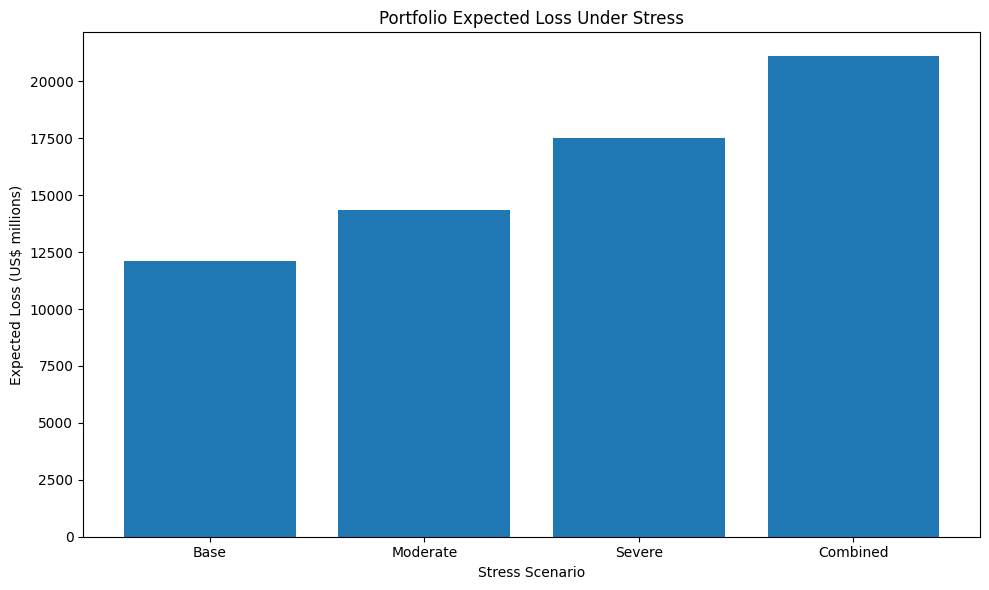

In [26]:
# Visualise portfolio expected loss under stress

plt.figure(figsize=(10, 6))

plt.bar(
    portfolio_loss_summary["Scenario"],
    portfolio_loss_summary["Expected_Loss"]
)

plt.ylabel("Expected Loss (US$ millions)")
plt.xlabel("Stress Scenario")
plt.title("Portfolio Expected Loss Under Stress")

plt.tight_layout()
plt.show()

In [27]:
# Identify the largest contributors to stressed expected loss

combined_loss = stress_expected_loss[
    stress_expected_loss["Scenario"] == "Combined"
].copy()

combined_loss = combined_loss.merge(
    df[["Ticker", "Company", "Sector", "Total_Debt"]],
    on="Ticker",
    how="left"
)

total_combined_loss = combined_loss["Expected_Loss"].sum()

combined_loss["Loss_Contribution_%"] = (
    combined_loss["Expected_Loss"]
    / total_combined_loss
    * 100
)

combined_loss = combined_loss.sort_values(
    "Expected_Loss",
    ascending=False
)

combined_loss[[
    "Company",
    "Ticker",
    "Sector",
    "Total_Debt",
    "Stress_PD",
    "Expected_Loss",
    "Loss_Contribution_%"
]]

,Company,Ticker,Sector,Total_Debt,Stress_PD,Expected_Loss,Loss_Contribution_%
0,Verizon Communications,VZ,Telecommunications,158150,0.260604,16485.816013,78.135790
1,PepsiCo,PEP,Consumer Staples,49182,0.139777,2749.797904,13.032878
2,Union Pacific,UNP,Industrials,31814,0.069085,879.150313,4.166800
3,Cisco Systems,CSCO,Technology,28093,0.035359,397.341240,1.883229
4,Exxon Mobil,XOM,Energy,43537,0.017575,306.068529,1.450635
5,FedEx,FDX,Transportation,19899,0.035273,280.756600,1.330667


In [28]:
# Calculate portfolio exposure by sector

sector_exposure = (
    df.groupby("Sector")["Total_Debt"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sector_exposure["Exposure_%"] = (
    sector_exposure["Total_Debt"]
    / sector_exposure["Total_Debt"].sum()
    * 100
)

sector_exposure

,Sector,Total_Debt,Exposure_%
0,Telecommunications,158150,47.826416
1,Consumer Staples,49182,14.873214
2,Energy,43537,13.166100
3,Industrials,31814,9.620927
4,Technology,28093,8.495653
5,Transportation,19899,6.017691


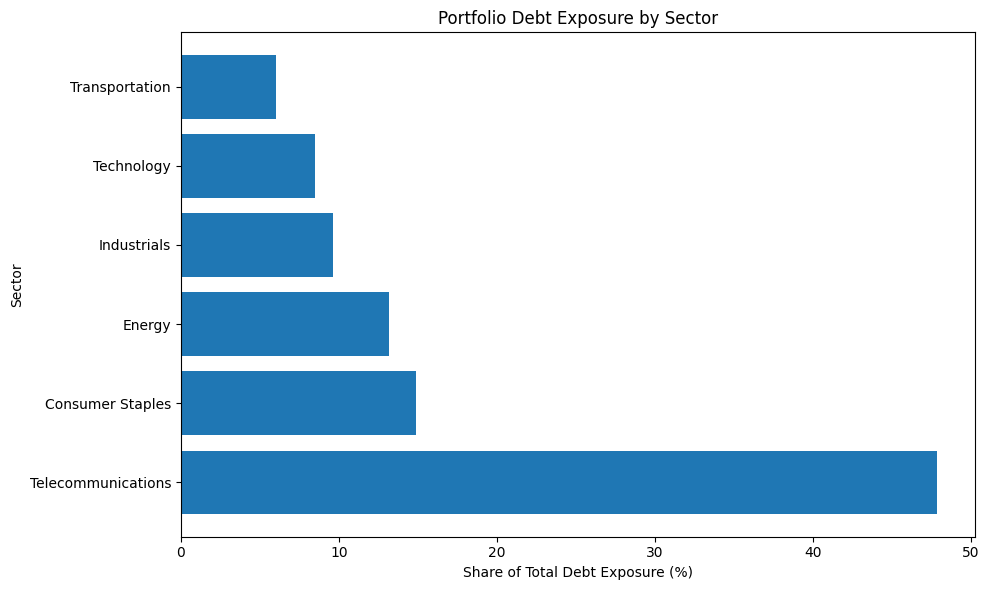

In [29]:
# Visualise portfolio exposure by sector

plt.figure(figsize=(10, 6))

plt.barh(
    sector_exposure["Sector"],
    sector_exposure["Exposure_%"]
)

plt.xlabel("Share of Total Debt Exposure (%)")
plt.ylabel("Sector")
plt.title("Portfolio Debt Exposure by Sector")

plt.tight_layout()
plt.show()

In [30]:
# Calculate borrower concentration

borrower_concentration = df[[
    "Company",
    "Ticker",
    "Sector",
    "Total_Debt"
]].copy()

total_portfolio_debt = borrower_concentration["Total_Debt"].sum()

borrower_concentration["Exposure_%"] = (
    borrower_concentration["Total_Debt"]
    / total_portfolio_debt
    * 100
)

borrower_concentration = borrower_concentration.sort_values(
    "Exposure_%",
    ascending=False
)

borrower_concentration

,Company,Ticker,Sector,Total_Debt,Exposure_%
0,Verizon Communications,VZ,Telecommunications,158150,47.826416
2,PepsiCo,PEP,Consumer Staples,49182,14.873214
1,Exxon Mobil,XOM,Energy,43537,13.166100
4,Union Pacific,UNP,Industrials,31814,9.620927
3,Cisco Systems,CSCO,Technology,28093,8.495653
5,FedEx,FDX,Transportation,19899,6.017691


In [31]:
# Calculate borrower concentration metrics

exposure_shares = (
    borrower_concentration["Exposure_%"] / 100
)

top_1_concentration = exposure_shares.iloc[0] * 100

top_2_concentration = (
    exposure_shares.iloc[:2].sum() * 100
)

hhi = (
    exposure_shares ** 2
).sum() * 10000

concentration_summary = pd.DataFrame({
    "Metric": [
        "Top 1 borrower concentration",
        "Top 2 borrower concentration",
        "Borrower concentration HHI"
    ],
    "Value": [
        top_1_concentration,
        top_2_concentration,
        hhi
    ]
})

concentration_summary

,Metric,Value
0,Top 1 borrower concentration,47.826416
1,Top 2 borrower concentration,62.699630
2,Borrower concentration HHI,2882.875664


## Qualitative Credit Risk Factors

Financial ratios provide an important view of credit quality, but quantitative metrics do not capture every source of borrower risk.

For each company, the analysis therefore considers selected qualitative factors identified in the companies' FY2025 annual filings.

| Company | Sector | Key qualitative risk factors |
|---|---|---|
| Verizon Communications | Telecommunications | Competitive pressure, regulatory exposure and high capital intensity |
| Exxon Mobil | Energy | Oil and gas price volatility, commodity exposure and cyclicality |
| PepsiCo | Consumer Staples | Commodity and transportation costs, labour costs, tariffs and supply-chain disruption |
| Cisco Systems | Technology | Technological change, competitive pressure, supply-chain exposure and purchase commitments |
| Union Pacific | Industrials | Labour relations, regulation, trade policy and competition from alternative transport modes |
| FedEx | Transportation | Economic cyclicality, fuel costs, labour costs and trade conditions |

These factors are not incorporated directly into the quantitative credit scores or expected-loss calculations.

They are included to demonstrate an important limitation of purely quantitative credit models: two companies with similar financial ratios may face materially different underlying business risks.

The qualitative assessment is based on risk factors disclosed in the companies' FY2025 annual filings.

In [32]:
# Create qualitative risk dataset

qualitative_risks = pd.DataFrame({
    "Ticker": [
        "VZ",
        "XOM",
        "PEP",
        "CSCO",
        "UNP",
        "FDX"
    ],

    "Qualitative_Risk": [
        "Competitive pressure, regulatory exposure and high capital intensity",
        "Oil and gas price volatility, commodity exposure and cyclicality",
        "Commodity and transportation costs, labour costs, tariffs and supply-chain disruption",
        "Technological change, competitive pressure, supply-chain exposure and purchase commitments",
        "Labour relations, regulation, trade policy and competition from alternative transport modes",
        "Economic cyclicality, fuel costs, labour costs and trade conditions"
    ]
})

qualitative_risks

,Ticker,Qualitative_Risk
0,VZ,"Competitive pressure, regulatory exposure and ..."
1,XOM,"Oil and gas price volatility, commodity exposu..."
2,PEP,"Commodity and transportation costs, labour cos..."
3,CSCO,"Technological change, competitive pressure, su..."
4,UNP,"Labour relations, regulation, trade policy and..."
5,FDX,"Economic cyclicality, fuel costs, labour costs..."


In [33]:
# Combine quantitative and qualitative credit analysis

credit_analysis = df.merge(
    qualitative_risks,
    on="Ticker",
    how="left"
)

credit_analysis[[
    "Company",
    "Ticker",
    "Sector",
    "Credit_Resilience_Score",
    "Net_Leverage",
    "Interest_Coverage",
    "Liquidity_Coverage",
    "Qualitative_Risk"
]]

,Company,Ticker,Sector,Credit_Resilience_Score,Net_Leverage,Interest_Coverage,Liquidity_Coverage,Qualitative_Risk
0,Verizon Communications,VZ,Telecommunications,20.000000,2.915268,7.128025,1.023096,"Competitive pressure, regulatory exposure and ..."
1,Exxon Mobil,XOM,Energy,90.000000,0.576988,94.434494,1.148989,"Oil and gas price volatility, commodity exposu..."
2,PepsiCo,PEP,Consumer Staples,40.000000,2.677303,8.124457,1.334937,"Commodity and transportation costs, labour cos..."
3,Cisco Systems,CSCO,Technology,73.333333,1.273671,9.732580,1.595183,"Technological change, competitive pressure, su..."
4,Union Pacific,UNP,Industrials,48.333333,2.360742,9.885409,0.832895,"Labour relations, regulation, trade policy and..."
5,FedEx,FDX,Transportation,78.333333,1.371927,13.300380,4.013129,"Economic cyclicality, fuel costs, labour costs..."


In [34]:
# Create final company-level credit dashboard

credit_dashboard = credit_analysis[[
    "Company",
    "Ticker",
    "Sector",
    "Credit_Resilience_Score",
    "Base_PD",
    "Net_Leverage",
    "Interest_Coverage",
    "Liquidity_Coverage",
    "Qualitative_Risk"
]].copy()

credit_dashboard = credit_dashboard.sort_values(
    "Credit_Resilience_Score",
    ascending=False
)

credit_dashboard

,Company,Ticker,Sector,Credit_Resilience_Score,Base_PD,Net_Leverage,Interest_Coverage,Liquidity_Coverage,Qualitative_Risk
1,Exxon Mobil,XOM,Energy,90.000000,0.01,0.576988,94.434494,1.148989,"Oil and gas price volatility, commodity exposu..."
5,FedEx,FDX,Transportation,78.333333,0.02,1.371927,13.300380,4.013129,"Economic cyclicality, fuel costs, labour costs..."
3,Cisco Systems,CSCO,Technology,73.333333,0.02,1.273671,9.732580,1.595183,"Technological change, competitive pressure, su..."
4,Union Pacific,UNP,Industrials,48.333333,0.04,2.360742,9.885409,0.832895,"Labour relations, regulation, trade policy and..."
2,PepsiCo,PEP,Consumer Staples,40.000000,0.08,2.677303,8.124457,1.334937,"Commodity and transportation costs, labour cos..."
0,Verizon Communications,VZ,Telecommunications,20.000000,0.15,2.915268,7.128025,1.023096,"Competitive pressure, regulatory exposure and ..."


In [35]:
# Calculate portfolio-level headline metrics

portfolio_metrics = pd.DataFrame({
    "Metric": [
        "Total debt exposure",
        "Average net leverage",
        "Average interest coverage",
        "Average liquidity coverage",
        "Top borrower exposure",
        "Top two borrower exposure"
    ],
    
    "Value": [
        df["Total_Debt"].sum(),
        df["Net_Leverage"].mean(),
        df["Interest_Coverage"].mean(),
        df["Liquidity_Coverage"].mean(),
        borrower_concentration["Exposure_%"].iloc[0],
        borrower_concentration["Exposure_%"].iloc[:2].sum()
    ]
})

portfolio_metrics

,Metric,Value
0,Total debt exposure,330675.000000
1,Average net leverage,1.862650
2,Average interest coverage,23.767557
3,Average liquidity coverage,1.658038
4,Top borrower exposure,47.826416
5,Top two borrower exposure,62.699630


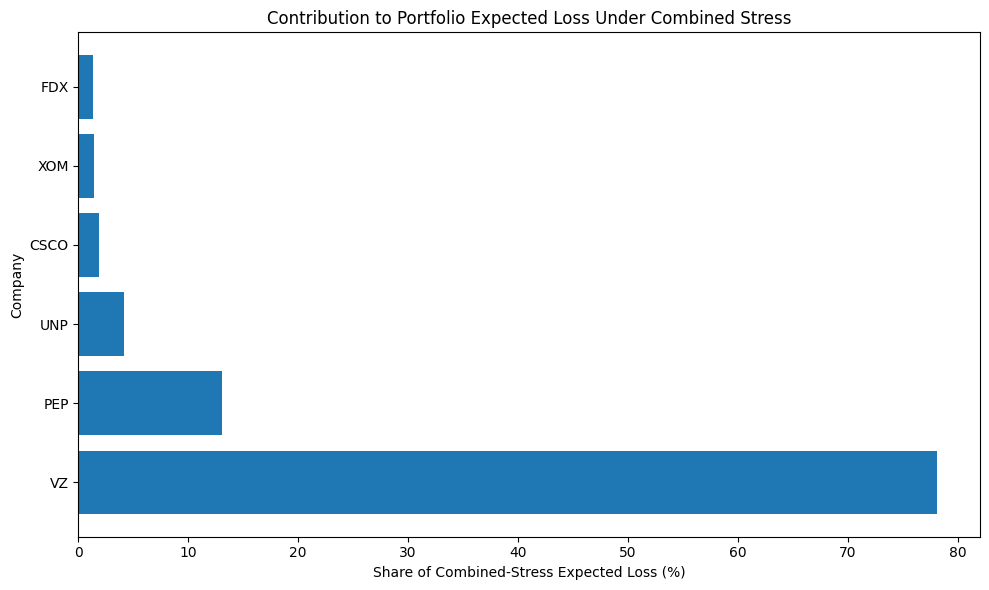

In [36]:
# Visualise contribution to combined-stress expected loss

loss_contribution = combined_loss.sort_values(
    "Loss_Contribution_%",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    loss_contribution["Ticker"],
    loss_contribution["Loss_Contribution_%"]
)

plt.xlabel("Share of Combined-Stress Expected Loss (%)")
plt.ylabel("Company")
plt.title("Contribution to Portfolio Expected Loss Under Combined Stress")

plt.tight_layout()
plt.show()

## Data Sources

The financial data used in this analysis was obtained from the companies' FY2025 annual filings submitted to the U.S. Securities and Exchange Commission (SEC).

| Company | Ticker | Source |
|---|---|---|
| Verizon Communications | VZ | Verizon FY2025 Form 10-K |
| Exxon Mobil | XOM | Exxon Mobil FY2025 Form 10-K |
| PepsiCo | PEP | PepsiCo FY2025 Form 10-K |
| Cisco Systems | CSCO | Cisco FY2025 Form 10-K |
| Union Pacific | UNP | Union Pacific FY2025 Form 10-K |
| FedEx | FDX | FedEx FY2025 Form 10-K |

The analysis uses reported financial statement figures and company disclosures. EBITDA has been standardised using reported components to improve comparability across companies.

All financial figures are presented in US$ millions.

### Source links

- [Verizon FY2025 SEC filings](https://www.sec.gov/edgar/browse/?CIK=732712&owner=exclude&action=getcompany)
- [Exxon Mobil FY2025 SEC filings](https://www.sec.gov/edgar/browse/?CIK=34088&owner=exclude&action=getcompany)
- [PepsiCo FY2025 SEC filings](https://www.sec.gov/edgar/browse/?CIK=77476&owner=exclude&action=getcompany)
- [Cisco Systems FY2025 SEC filings](https://www.sec.gov/edgar/browse/?CIK=858877&owner=exclude&action=getcompany)
- [Union Pacific FY2025 SEC filings](https://www.sec.gov/edgar/browse/?CIK=100885&owner=exclude&action=getcompany)
- [FedEx FY2025 SEC filings](https://www.sec.gov/edgar/browse/?CIK=1048911&owner=exclude&action=getcompany)

## Key Findings

The analysis highlights several important features of the portfolio's credit profile.

### 1. Leverage varies materially across borrowers

Net leverage differs substantially across the six companies, demonstrating that companies with large absolute debt balances can have very different levels of balance-sheet leverage once earnings and cash holdings are considered.

### 2. Debt-servicing capacity is uneven

Interest coverage varies considerably across the portfolio. Exxon Mobil has particularly high interest coverage relative to the other companies, while companies with higher interest burdens have substantially less capacity to absorb an earnings decline.

### 3. Liquidity provides an additional dimension of credit resilience

Cash relative to short-term debt varies across the portfolio. This highlights why leverage alone is insufficient when assessing a borrower's ability to withstand short-term financial pressure.

### 4. Stress testing materially changes credit metrics

Under the combined stress scenario, EBITDA declines by 30%, interest expense increases by 35% and cash declines by 15%.

As a result, net leverage increases while interest coverage and liquidity coverage deteriorate across the portfolio.

This demonstrates how simultaneous deterioration in operating performance, financing costs and liquidity can amplify credit risk.

### 5. Portfolio concentration is significant

The largest borrower represents approximately 47.8% of total debt exposure, while the two largest borrowers represent approximately 62.7%.

This means that portfolio-level credit risk is influenced substantially by a small number of borrowers, despite the portfolio containing six companies across different sectors.

### 6. Quantitative metrics do not capture all credit risk

The qualitative assessment identifies sector-specific risks including commodity-price exposure, regulation, technological change, labour costs, supply-chain disruption and economic cyclicality.

These factors are not incorporated directly into the quantitative credit score, illustrating an important limitation of purely ratio-based credit analysis.

### Overall interpretation

The analysis demonstrates how a credit-risk framework can combine financial statement analysis, relative credit metrics, stress testing, expected-loss modelling and portfolio concentration analysis to assess borrower and portfolio-level risk.

The results should be interpreted as an illustrative analytical framework rather than as predictions of default or a substitute for professional credit underwriting.

## Limitations

Several limitations should be considered when interpreting the results of this analysis.

### Illustrative credit scoring framework

The Credit Resilience Score is a relative measure based only on the six companies in the sample. The percentile-based scoring system and assigned weights are illustrative and should not be interpreted as an external credit rating.

### Simplified probability of default

Probability of default is mapped to broad bands using the Credit Resilience Score. These probabilities are illustrative assumptions rather than observed, market-implied or statistically estimated default probabilities.

A professional credit model would typically incorporate a much larger dataset and additional variables such as historical defaults, credit spreads, ratings, financial trends and macroeconomic conditions.

### Simplified expected-loss framework

Expected loss is calculated using assumed LGD of 40% and total debt as a proxy for exposure at default. Actual recovery rates and lender exposures can differ materially depending on collateral, seniority, guarantees, covenants and capital structure.

### Stress assumptions

The stress scenarios apply the same percentage changes to each company. In reality, the impact of a recession, higher interest rates or reduced liquidity would vary significantly by sector and company.

### Limited historical period

The analysis uses FY2025 financial data. A single reporting period does not capture changes in credit quality over time or the full range of a company's financial cycle.

### Fiscal year differences

The companies have different fiscal year-end dates. Although all observations represent FY2025 reporting periods, the underlying economic conditions are not necessarily measured on exactly the same date.

### Qualitative risk factors

Qualitative risks are identified from company disclosures but are not incorporated directly into the quantitative credit score or expected-loss calculation. This means the model cannot fully capture differences in business-model resilience, management actions or industry-specific risks.

### Model purpose

The framework is designed as an educational and analytical exercise demonstrating credit-risk modelling techniques. It is not intended to predict actual defaults, determine investment suitability or replace professional credit underwriting.

In [37]:
# Create a final summary table for the completed credit-risk model

final_summary = df[[
    "Company",
    "Ticker",
    "Sector",
    "Gross_Leverage",
    "Net_Leverage",
    "Interest_Coverage",
    "Liquidity_Coverage",
    "Credit_Resilience_Score",
    "Base_PD",
    "Base_Expected_Loss"
]].copy()

final_summary = final_summary.sort_values(
    "Credit_Resilience_Score",
    ascending=False
)

final_summary

,Company,Ticker,Sector,Gross_Leverage,Net_Leverage,Interest_Coverage,Liquidity_Coverage,Credit_Resilience_Score,Base_PD,Base_Expected_Loss
1,Exxon Mobil,XOM,Energy,0.764558,0.576988,94.434494,1.148989,90.000000,0.01,174.148
5,FedEx,FDX,Transportation,1.896226,1.371927,13.300380,4.013129,78.333333,0.02,159.192
3,Cisco Systems,CSCO,Technology,1.811984,1.273671,9.732580,1.595183,73.333333,0.02,224.744
4,Union Pacific,UNP,Industrials,2.458578,2.360742,9.885409,0.832895,48.333333,0.04,509.024
2,PepsiCo,PEP,Consumer Staples,3.289986,2.677303,8.124457,1.334937,40.000000,0.08,1573.824
0,Verizon Communications,VZ,Telecommunications,3.314471,2.915268,7.128025,1.023096,20.000000,0.15,9489.000


In [38]:
# Format the final summary for presentation

final_summary_display = final_summary.copy()

final_summary_display["Gross_Leverage"] = final_summary_display["Gross_Leverage"].round(2)
final_summary_display["Net_Leverage"] = final_summary_display["Net_Leverage"].round(2)
final_summary_display["Interest_Coverage"] = final_summary_display["Interest_Coverage"].round(2)
final_summary_display["Liquidity_Coverage"] = final_summary_display["Liquidity_Coverage"].round(2)
final_summary_display["Credit_Resilience_Score"] = final_summary_display["Credit_Resilience_Score"].round(1)
final_summary_display["Base_PD"] = (final_summary_display["Base_PD"] * 100).round(1).astype(str) + "%"
final_summary_display["Base_Expected_Loss"] = final_summary_display["Base_Expected_Loss"].round(1)

final_summary_display

,Company,Ticker,Sector,Gross_Leverage,Net_Leverage,Interest_Coverage,Liquidity_Coverage,Credit_Resilience_Score,Base_PD,Base_Expected_Loss
1,Exxon Mobil,XOM,Energy,0.76,0.58,94.43,1.15,90.0,1.0%,174.1
5,FedEx,FDX,Transportation,1.90,1.37,13.30,4.01,78.3,2.0%,159.2
3,Cisco Systems,CSCO,Technology,1.81,1.27,9.73,1.60,73.3,2.0%,224.7
4,Union Pacific,UNP,Industrials,2.46,2.36,9.89,0.83,48.3,4.0%,509.0
2,PepsiCo,PEP,Consumer Staples,3.29,2.68,8.12,1.33,40.0,8.0%,1573.8
0,Verizon Communications,VZ,Telecommunications,3.31,2.92,7.13,1.02,20.0,15.0%,9489.0


**Conclusion**
This project demonstrates a structured approach to corporate credit-risk analysis using publicly available financial data.

The framework combines:

* financial statement analysis
* leverage and debt-servicing metrics
* liquidity analysis
* relative credit-resilience scoring
* borrower and sector concentration analysis
* qualitative risk assessment
* scenario-based stress testing
* expected-loss modelling
The stress-testing framework illustrates how simultaneous deterioration in operating performance, financing costs and liquidity can materially affect borrower-level credit metrics and portfolio expected losses.

The analysis also highlights the importance of combining quantitative and qualitative information. Financial ratios provide a measurable framework for comparing borrowers, while company-specific and sector-specific factors provide additional context that cannot be captured through ratios alone.

The project is intentionally illustrative. Its purpose is to demonstrate the application of financial modelling and credit-risk concepts rather than to produce investment recommendations, credit ratings or predictions of default.